In [24]:
import sys, subprocess, torch
print('python:', sys.executable)
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('cuda_available:', torch.cuda.is_available())
print('device_count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu0:', torch.cuda.get_device_name(0))
try:
    out = subprocess.run(['nvidia-smi', '--query-gpu=name,driver_version', '--format=csv,noheader'], capture_output=True, text=True, timeout=15)
    print('nvidia-smi:', out.stdout.strip() if out.returncode == 0 else out.stderr.strip())
except Exception as e:
    print('nvidia-smi error:', repr(e))

python: c:\Users\Santi\miniconda3\envs\GenD\python.exe
torch: 2.8.0+cu128
torch.version.cuda: 12.8
cuda_available: True
device_count: 1
gpu0: NVIDIA GeForce RTX 4060
nvidia-smi: NVIDIA GeForce RTX 4060, 581.80


In [25]:
import requests
import torch
from PIL import Image

from src.hf.modeling_gend import GenD

import torch
from PIL import Image
import os
import glob
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm

from detector import process_image

# Preprocess Imgs

In [26]:
# run detector.py on every image from imgs/evaluation/real and imgs/evaluation/fake,
# and save them within imgs/evaluation/real_processed and imgs/evaluation/fake_processed
from src.retinaface import prepare_model

#scale_factors = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5]
scale_factor = 1.33
det_thres = 0.72
nms_thresh = 0.72

test = False

# Initialize once to avoid reloading the detector per image/sequence.
if "model" not in globals():
    model = prepare_model(det_thres=det_thres, nms_thresh=nms_thresh)

root_dir = 'imgs/evaluation'
for folder in ['real', 'fake']:
    input_dir = os.path.join(root_dir, folder)
    output_dir = os.path.join(root_dir, f'{folder}_processed')
    if test:
        output_dir = os.path.join(root_dir, f'{folder}_processed_{scale_factor}_det{det_thres}_nms{nms_thresh}')
    os.makedirs(output_dir, exist_ok=True)

    # folder has many folders, we will call these sequences, and each sequence has many images
    sequences = glob.glob(os.path.join(input_dir, '*'))
    for sequence in sequences:
        # process each image in the sequence and save it to the output directory
        images = glob.glob(os.path.join(sequence, '*.jpg'))  # assuming images are in jpg format
        for image in images:
            process_image(
                image,
                os.path.join(output_dir, os.path.join(os.path.basename(sequence), os.path.basename(image))),
                model,
                scale=scale_factor
            )

Processing imgs/evaluation\real\id0_0003\id0_0003_000.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_001.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_002.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_003.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_004.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_005.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_006.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluation\real\id0_0003\id0_0003_007.jpg
Error during detection: 'GenD' object has no attribute 'detect'
Processing imgs/evaluati

In [27]:
# # run detector.py on every image from imgs/evaluation/real and imgs/evaluation/fake,
# # and save them within imgs/evaluation/real_processed and imgs/evaluation/fake_processed
# from src.retinaface import prepare_model

# #scale_factors = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5]
# scale_factors = [1.30, 1.31 , 1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39]

# for scale_factor in scale_factors:
#     # Initialize once to avoid reloading the detector per image/sequence.
#     if "model" not in globals():
#         model = prepare_model(det_thres=0.5, nms_thresh=0.4)

#     root_dir = 'imgs/evaluation'
#     for folder in ['real', 'fake']:
#         input_dir = os.path.join(root_dir, folder)
#         output_dir = os.path.join(root_dir, f'{folder}_processed_{scale_factor}')
#         os.makedirs(output_dir, exist_ok=True)

#         # folder has many folders, we will call these sequences, and each sequence has many images
#         sequences = glob.glob(os.path.join(input_dir, '*'))
#         for sequence in sequences:
#             # process each image in the sequence and save it to the output directory
#             images = glob.glob(os.path.join(sequence, '*.jpg'))  # assuming images are in jpg format
#             for image in images:
#                 process_image(
#                     image,
#                     os.path.join(output_dir, os.path.join(os.path.basename(sequence), os.path.basename(image))),
#                     model,
#                     scale=scale_factor
#                 )

# Inference

### test

In [28]:
model = GenD.from_pretrained("yermandy/GenD_CLIP_L_14")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

model = model.to(device).eval()

imgs = [
    "imgs/real.png",
    "imgs/fake.png"
]
images = [Image.open(img).convert("RGB") for img in imgs]
tensors = torch.stack([model.feature_extractor.preprocess(img) for img in images]).to(device)
with torch.no_grad():
    logits = model(tensors)
    probs = logits.softmax(dim=-1)

    print(probs)


CUDA available: True
GPU: NVIDIA GeForce RTX 4060
tensor([[0.6808, 0.3192],
        [0.0330, 0.9670]], device='cuda:0')


In [29]:
from pathlib import Path

#scale_factors = [0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5]
scale_factor = 1.33

real_data_path = Path(f"imgs/evaluation/real_processed")
fake_data_path = Path(f"imgs/evaluation/fake_processed")

if test:
    real_data_path = Path(f"imgs/evaluation/real_processed_{scale_factor}_det{det_thres}_nms{nms_thresh}")
    fake_data_path = Path(f"imgs/evaluation/fake_processed_{scale_factor}_det{det_thres}_nms{nms_thresh}")

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# Label convention in this repo: 0=real, 1=fake
LABEL_REAL = 0
LABEL_FAKE = 1

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def collect_images(root: Path):
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in image_exts])


def perform_prediction_with_processing(image_path, model, device):
    image = Image.open(image_path).convert("RGB")
    tensor = model.feature_extractor.preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=-1)

    prob_fake = probs[0, LABEL_FAKE].item()
    pred_label = LABEL_FAKE if prob_fake >= 0.5 else LABEL_REAL
    return pred_label, prob_fake


# Lists for metrics
true_labels = []
pred_labels = []
prob_fake_scores = []

# Evaluate real and fake folders recursively
samples = [(p, LABEL_REAL) for p in collect_images(real_data_path)] + [(p, LABEL_FAKE) for p in collect_images(fake_data_path)]

if len(samples) != 600:
    raise ValueError(f"Expected 600 images (300 real + 300 fake), but found {len(samples)}. Please check the dataset paths and contents.")

if len(samples) == 0:
    raise ValueError(f"No images found in {real_data_path} or {fake_data_path}")

print(f"Starting evaluation on {len(samples)} images...")

predictions = []

for file_path, true_label in tqdm(samples, desc="Evaluating images"):
    pred_label, prob_fake = perform_prediction_with_processing(file_path, model, device)
    true_labels.append(true_label)
    pred_labels.append(pred_label)
    prob_fake_scores.append(prob_fake)

    # append to prediction list [file_path, pred_label]
    predictions.append((file_path, pred_label, true_label))

print(f"\n{len(true_labels)} samples processed.")

Starting evaluation on 600 images...


Evaluating images: 100%|██████████| 600/600 [00:24<00:00, 24.43it/s]


600 samples processed.


<Figure size 800x600 with 0 Axes>

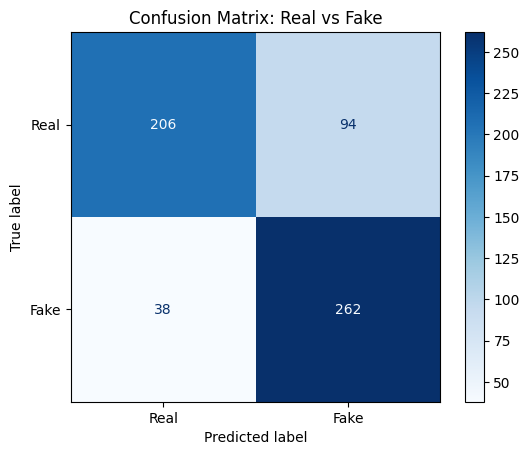

In [30]:
# --- Confusion Matrix ---
cm = confusion_matrix(true_labels, pred_labels, labels=[LABEL_REAL, LABEL_FAKE])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix: Real vs Fake")
plt.savefig("confusion_matrix_final.png")
plt.show()


Area Under the Curve (AUC): 0.8857


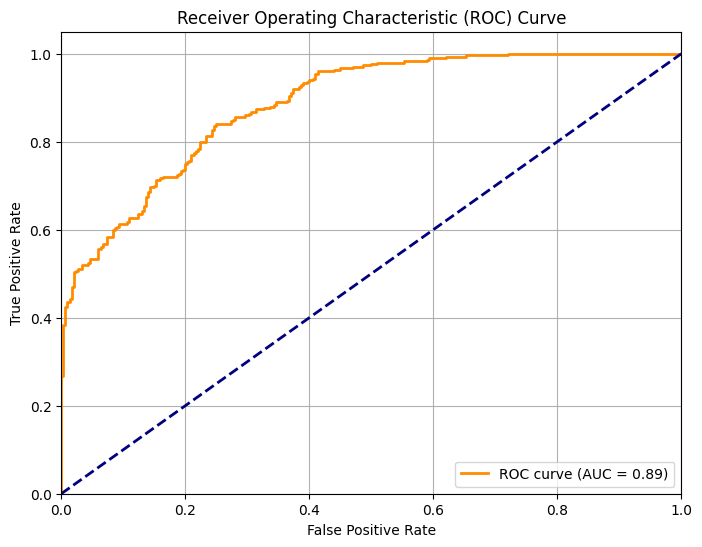

In [31]:
# --- AUC (fake is positive class) ---
try:
    auc_score = roc_auc_score(true_labels, prob_fake_scores)
    print(f"Area Under the Curve (AUC): {auc_score:.4f}")

    fpr, tpr, _ = roc_curve(true_labels, prob_fake_scores)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_score:.2f})")
    plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig("roc_curve_final.png")
    plt.show()
except ValueError as e:
    print(f"Could not calculate AUC: {e}")

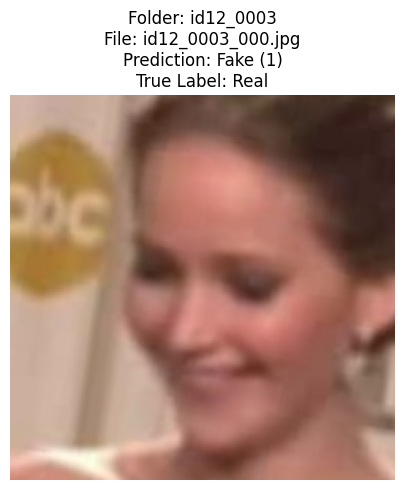

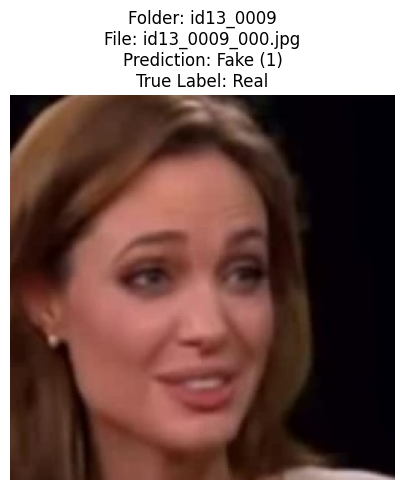

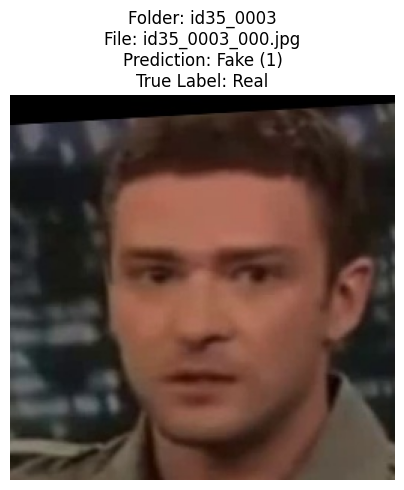

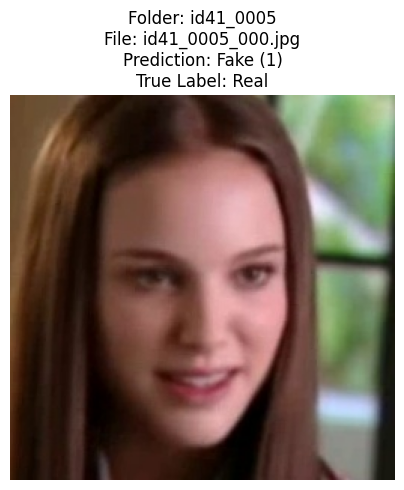

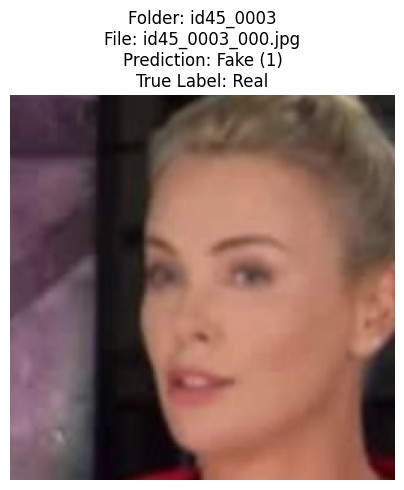

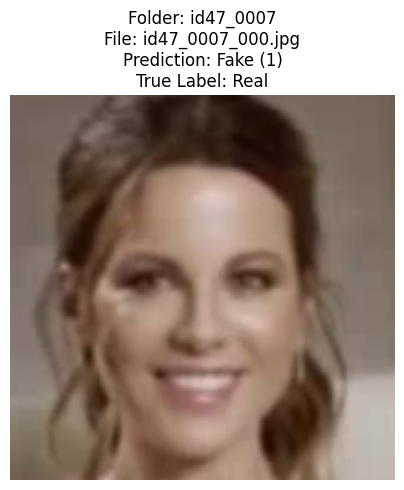

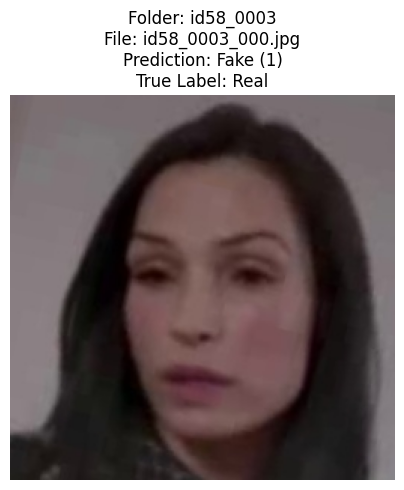

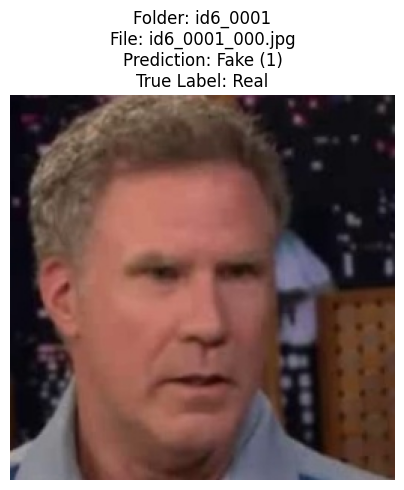

In [39]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


def build_prediction_lookup(predictions):
    prediction_lookup = {}
    for image_path, pred_label, true_label in predictions:
        normalized_path = str(Path(image_path))
        prediction_lookup[normalized_path] = {
            "label_id": pred_label,
            "pred_label": "Fake" if pred_label == LABEL_FAKE else "Real",
            "true_label": "Fake" if true_label == LABEL_FAKE else "Real"
        }
    return prediction_lookup


prediction_lookup = build_prediction_lookup(predictions)


def plot_one_image_per_folder(root_path):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    subdirs = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

    if not subdirs:
        print(f"No subfolders found in {root_path}")
        return

    for subdir in subdirs:
        folder_path = os.path.join(root_path, subdir)
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

        if not images:
            print(f"No supported images found in folder: {subdir}")
            continue
        
        # check the first image detected as fake
        fake_images = [f for f in images if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        if not fake_images:
            continue
        img_path = os.path.join(folder_path, fake_images[0])
        normalized_img_path = str(Path(img_path))
        pred = prediction_lookup.get(normalized_img_path)

        if pred is None:
            print(f"No prediction found for {img_path}")
            continue

        if pred["label_id"] == LABEL_REAL:
            continue

        if pred["true_label"] == "Fake":
            continue

        try:
            with Image.open(img_path) as img:
                plt.figure(figsize=(5, 5))
                plt.imshow(img)
                plt.title(
                    f"Folder: {subdir}\n"
                    f"File: {images[0]}\n"
                    f"Prediction: {pred['pred_label']} ({pred['label_id']})\n"
                    f"True Label: {pred['true_label']}"
                )
                plt.axis('off')
                plt.show()
        except Exception as e:
            print(f"Error opening {img_path}: {e}")


main_folder = 'imgs/evaluation/real_processed'
if os.path.exists(main_folder):
    plot_one_image_per_folder(main_folder)
else:
    print(f"Directory '{main_folder}' not found.")

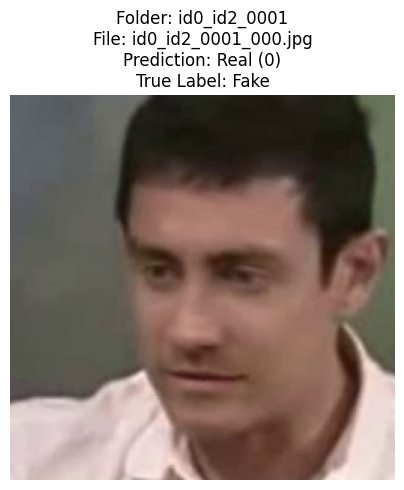

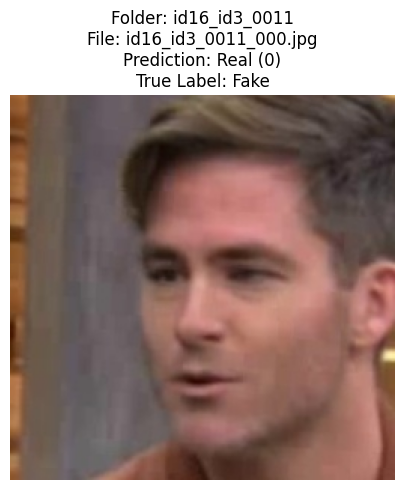

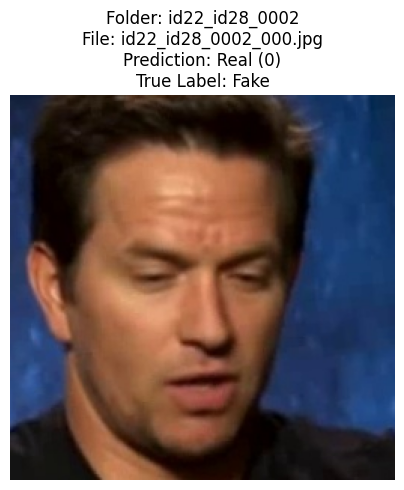

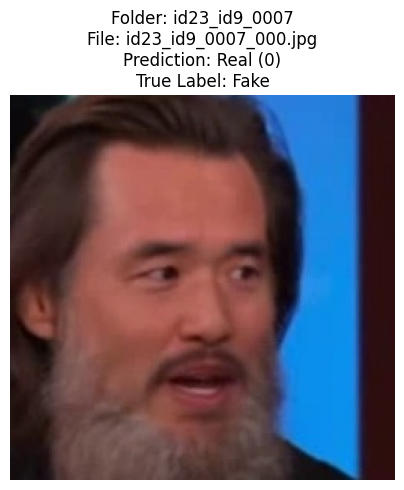

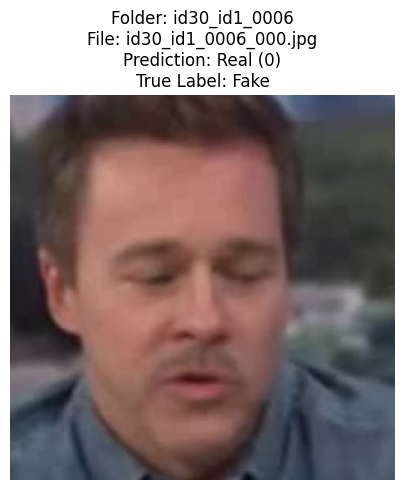

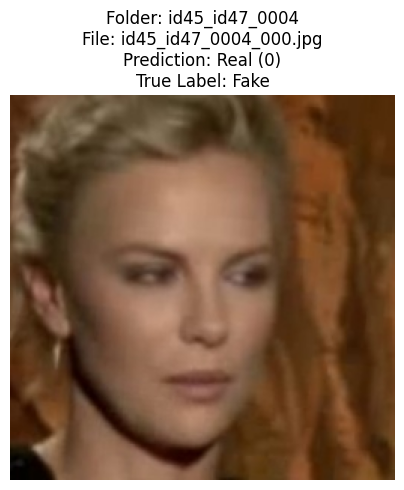

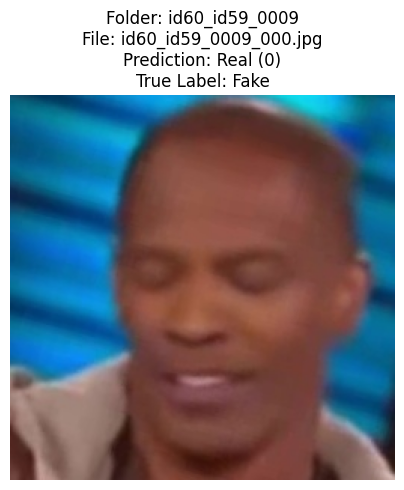

In [41]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image


def build_prediction_lookup(predictions):
    prediction_lookup = {}
    for image_path, pred_label, true_label in predictions:
        normalized_path = str(Path(image_path))
        prediction_lookup[normalized_path] = {
            "label_id": pred_label,
            "pred_label": "Fake" if pred_label == LABEL_FAKE else "Real",
            "true_label": "Fake" if true_label == LABEL_FAKE else "Real"
        }
    return prediction_lookup


prediction_lookup = build_prediction_lookup(predictions)


def plot_one_image_per_folder(root_path):
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')
    subdirs = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

    if not subdirs:
        print(f"No subfolders found in {root_path}")
        return

    for subdir in subdirs:
        folder_path = os.path.join(root_path, subdir)
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_extensions)]

        if not images:
            print(f"No supported images found in folder: {subdir}")
            continue
        
        # check the first image detected as fake
        real_images = [f for f in images if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))]
        if not real_images:
            continue
        img_path = os.path.join(folder_path, real_images[0])
        normalized_img_path = str(Path(img_path))
        pred = prediction_lookup.get(normalized_img_path)

        if pred is None:
            print(f"No prediction found for {img_path}")
            continue

        if pred["label_id"] == LABEL_FAKE:
            continue

        if pred["true_label"] == "Real":
            continue

        try:
            with Image.open(img_path) as img:
                plt.figure(figsize=(5, 5))
                plt.imshow(img)
                plt.title(
                    f"Folder: {subdir}\n"
                    f"File: {images[0]}\n"
                    f"Prediction: {pred['pred_label']} ({pred['label_id']})\n"
                    f"True Label: {pred['true_label']}"
                )
                plt.axis('off')
                plt.show()
        except Exception as e:
            print(f"Error opening {img_path}: {e}")


main_folder = 'imgs/evaluation/fake_processed'
if os.path.exists(main_folder):
    plot_one_image_per_folder(main_folder)
else:
    print(f"Directory '{main_folder}' not found.")